In [17]:
import numpy as np
import sympy as sp
import scipy as sc
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp


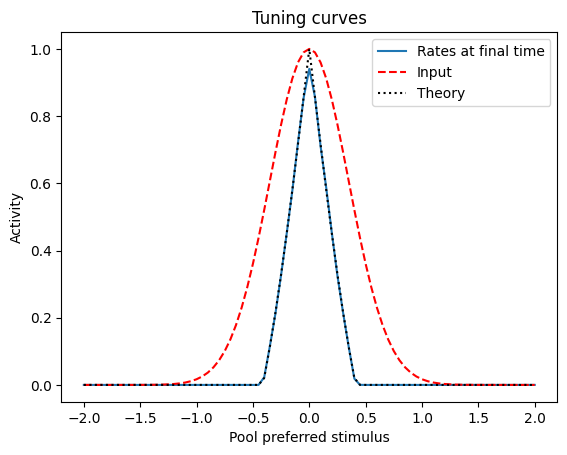

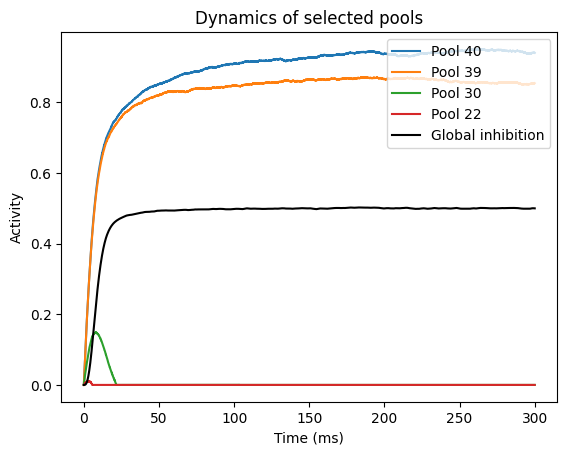

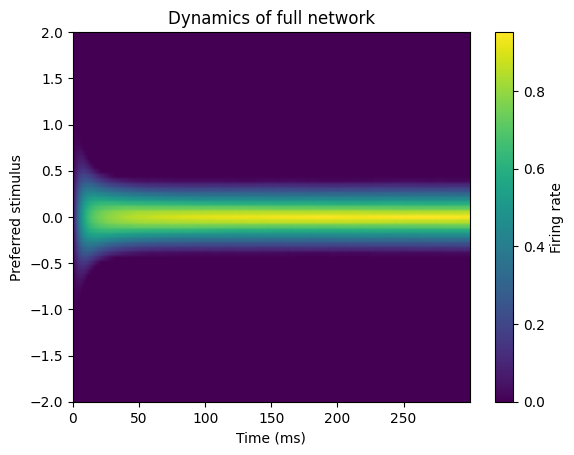

In [ ]:
# --------------------
# Parameters
# --------------------
num_pools        = 81       # number of excitatory pools
total_time_ms    = 300.0    # total simulation time (ms)
dt_ms            = 0.01      # timestep (ms)

tau_exc_ms       = 10.0     # excitatory time constant (ms)
tau_inh_ms       = 1.0      # inhibitory time constant (ms)
inhib_gain       = 1000.0     # global inhibitory gain
inhib_threshold  = 1.0      # threshold enforced by inhibition
w_EI             = 10.0     # weight of excitatory to inhibitory connections

# --------------------
# Stimulus (Gaussian input across pools)
# --------------------
preferred_stimuli = np.linspace(-2, 2, num_pools)   # preferred stimulus for each pool
stimulus_center   = 0.0                             # actual stimulus location
stimulus_amplitude = 1.0                            # peak strength of input
stimulus_width    = 0.35                            # tuning width
external_input = stimulus_amplitude * np.exp(
    -0.5 * ((preferred_stimuli - stimulus_center) / stimulus_width)**2
)
use_adapt = False  # set False to disable adaptation

# --------------------
# State variables
# --------------------
num_steps   = int(total_time_ms / dt_ms)
time_points = np.arange(num_steps) * dt_ms

exc_activity = np.zeros((num_steps, num_pools))   # firing rates of excitatory pools
inh_activity = np.zeros(num_steps)                # global inhibitory pool

# --------------------
# Simulation loop
# --------------------
for step in range(num_steps - 1):
    # Excitatory dynamics
    a, beta = 0.5, 0.0
    # add noise
    noise = np.random.normal(0, 0.1, size=exc_activity[step].shape)
    nonlinear_exc = a * exc_activity[step]**2 / (1 + beta * exc_activity[step]**2)
    d_exc = (-exc_activity[step] + nonlinear_exc + external_input - inh_activity[step] + noise) / tau_exc_ms
    exc_activity[step + 1] = np.maximum(exc_activity[step] + dt_ms * d_exc, 0.0)

    # # Inhibitory dynamics (driven by total suprathreshold activity)
    # suprathreshold_drive = np.maximum(exc_activity[step + 1] - inhib_threshold, 0).sum()
    # d_inh = (-inh_activity[step] + inhib_gain * suprathreshold_drive) / tau_inh_ms
    # inh_activity[step + 1] = max(inh_activity[step] + dt_ms * d_inh, 0.0)

    # # pooled excitatory drive (mean activity)
    # U = np.mean((exc_activity[step+1] ** p_pool)) ** (1/p_pool)
    p_pool = 2.5
    # U_drive = (exc_activity[step + 1]**p_pool).mean() / (exc_activity[step + 1].mean()**(p_pool - 1))  # = mean_e * U_shape
    U_drive = (exc_activity[step + 1]**p_pool).mean()
    # --- inhibition update (no delay, no adaptation) ---
    dI = (-inh_activity[step] + w_EI * U_drive) / tau_inh_ms
    inh_activity[step + 1] = max(inh_activity[step] + dt_ms * dI, 0.0)

# --------------------
# Plot results
# --------------------
# 1. Tuning curves
plt.figure()
plt.plot(preferred_stimuli, exc_activity[-1], label="Rates at final time")
plt.plot(preferred_stimuli, external_input, 'r--', label="Input")
x_max = external_input.max()
theory_curve = 1 - np.sqrt(np.maximum(0, (1-inhib_threshold)**2 + 2 * (x_max - external_input)))
# at the middle pool, theory curve can be the plus solution if inhib_threshold > 1
if inhib_threshold > 1:
    theory_curve[num_pools // 2] = 1 + np.sqrt(np.maximum(0, (inhib_threshold - 1)**2 + 2 * (x_max - external_input[num_pools // 2])))
plt.plot(preferred_stimuli, np.maximum(theory_curve, 0), 'k:', label="Theory")
plt.xlabel("Pool preferred stimulus")
plt.ylabel("Activity")
plt.legend()
plt.title("Tuning curves")
plt.show()

# 2. Dynamics of selected pools
plt.figure()
selected_pools = [num_pools//2, num_pools//2 - 1, num_pools//2 - 10, num_pools//2 - 18]
for idx in selected_pools:
    plt.plot(time_points, exc_activity[:, idx], label=f"Pool {idx}")
plt.plot(time_points, inh_activity, 'k', label="Global inhibition")
plt.xlabel("Time (ms)")
plt.ylabel("Activity")
plt.title("Dynamics of selected pools")
plt.legend(loc='upper right')
plt.show()

# 3. Heatmap of full network dynamics
plt.figure()
plt.imshow(exc_activity.T, aspect="auto", origin="lower",
           extent=[time_points[0], time_points[-1], preferred_stimuli[0], preferred_stimuli[-1]])
plt.colorbar(label="Firing rate")
plt.xlabel("Time (ms)")
plt.ylabel("Preferred stimulus")
plt.title("Dynamics of full network")
plt.show()


In [2]:
data_dirs = ['/home/reilly/Desktop/jacob data/data2.npy',
              '/home/reilly/Desktop/jacob data/data3.npy',
              '/home/reilly/Desktop/jacob data/data5.npy']
metadata_dirs = ['/home/reilly/Desktop/jacob data/meta2.mat',
                 '/home/reilly/Desktop/jacob data/meta3.mat',
                 '/home/reilly/Desktop/jacob data/meta5.mat']
response = np.zeros((15_166, 1026, 3))
for i in range(3):
    data = np.load(data_dirs[i]).T
    mat_data = sc.io.loadmat(metadata_dirs[i], simplify_cells=True)
    angles = np.array([entry['gratingOrient'] for entry in mat_data['block']['paramsValues']])
    response[:, :, i] = data[:, np.argsort(angles)]
angles_sorted = np.sort(angles)

In [3]:
# remove angles == 1
response = response[:, angles_sorted != 1, :]
angles_sorted = angles_sorted[angles_sorted != 1]


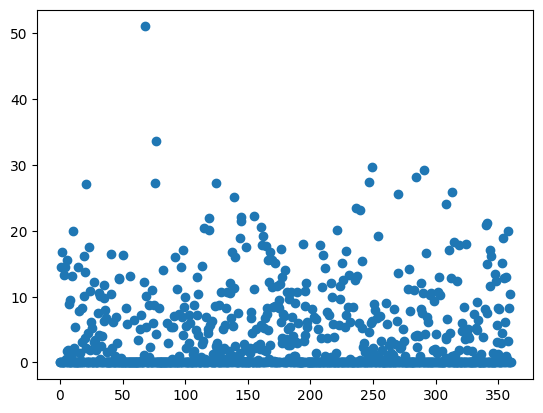

In [4]:
cell_index = np.random.randint(response.shape[0])
plt.scatter(angles_sorted, response[cell_index, :, 0])

In [5]:
# scale each cell over trials to have L2 norm 1
response = response / np.linalg.norm(response, axis=1, keepdims=True)


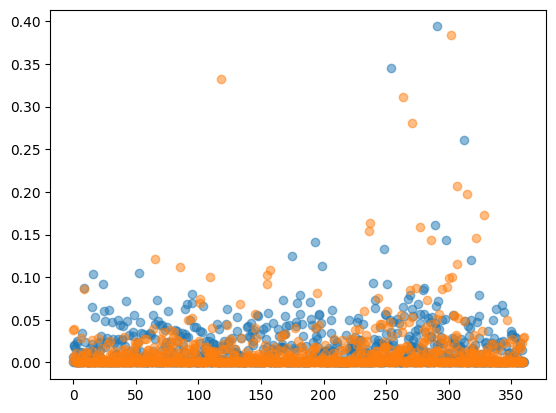

In [6]:
cell_index = np.random.randint(response.shape[0])
plt.scatter(angles_sorted, response[cell_index, :, 0], alpha=0.5)
plt.scatter(angles_sorted, response[cell_index, :, 1], alpha=0.5)
plt.show()

In [7]:
# wrap each cell's response around the unit circle and take the magnitude
circ_mean = np.zeros((response.shape[0], 3), dtype=complex)
angles_rad = np.deg2rad(angles_sorted)
for i in range(3):
    circ_mean[:, i] = np.mean(response[:, :, i] * np.exp(2j * angles_rad), axis=1) / np.mean(response[:, :, i], axis=1)
circ_magnitude = np.mean(np.abs(circ_mean), axis=-1)

In [8]:
good_cells = circ_magnitude > 0.5
response_cropped = response[good_cells]

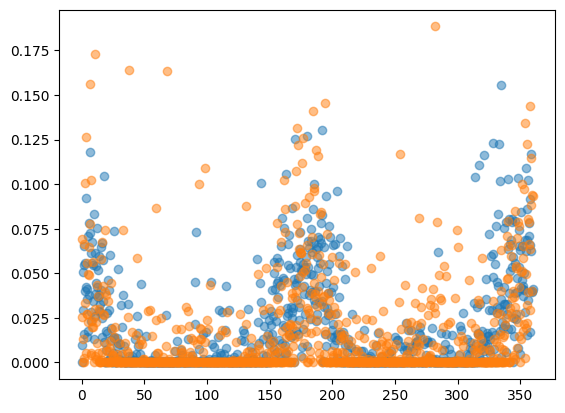

In [9]:
cell_index = np.random.randint(response_cropped.shape[0])
plt.scatter(angles_sorted, response_cropped[cell_index, :, 0], alpha=0.5)
plt.scatter(angles_sorted, response_cropped[cell_index, :, 1], alpha=0.5)
# plt.scatter(angles_sorted, response_cropped[cell_index, :, 2], alpha=0.5)


In [10]:
response_z = (response_cropped - response_cropped.mean(axis=1, keepdims=True)) / response_cropped.std(axis=1, keepdims=True)

(-0.01, 0.2)

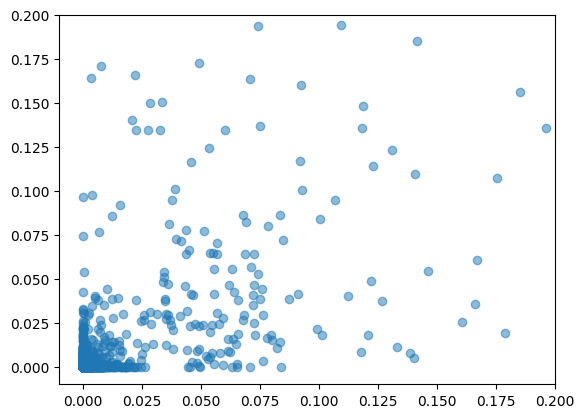

In [11]:
cell_index = np.random.randint(response_z.shape[0])
plt.scatter(response_cropped[cell_index, :, 0], response_cropped[cell_index, :, 1], alpha=0.5)
plt.xlim(-0.01, 0.2)
plt.ylim(-0.01, 0.2)
# plt.scatter(angles_sorted, response_z[cell_index, :, 2], alpha=0.5)


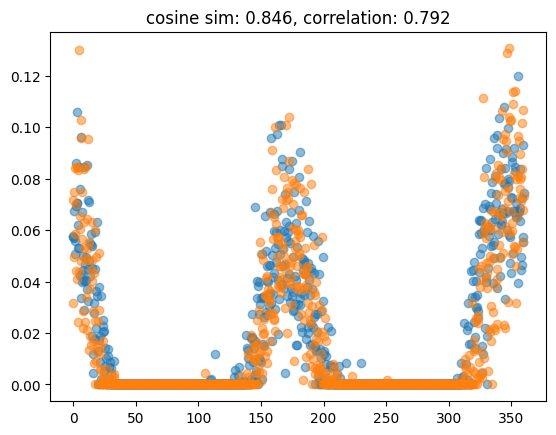

In [12]:
cell_index = np.random.randint(response_cropped.shape[0])
plt.scatter(angles_sorted, response_cropped[cell_index, :, 0], alpha=0.5)
plt.scatter(angles_sorted, response_cropped[cell_index, :, 1], alpha=0.5)
cosine_sim = np.sum(response_cropped[cell_index, :, 0] * response_cropped[cell_index, :, 1])
correlation = np.corrcoef(response_cropped[cell_index, :, 0], response_cropped[cell_index, :, 1])[0, 1]
plt.title(f'cosine sim: {cosine_sim:.3f}, correlation: {correlation:.3f}')
plt.show()

In [15]:
n_cells, n_trials, n_repeats = response_z.shape

In [13]:
response_z = (response_cropped - response_cropped.mean(axis=1, keepdims=True)) / response_cropped.std(axis=1, keepdims=True)

In [16]:
C = np.zeros((n_trials, n_trials, 3, 3))
for i, j in np.ndindex(3, 3):
    C[:, :, i, j] = response_z[:, :, i].T @ response_z[:, :, j] / n_cells

In [824]:
response_mean = np.mean(response_z, axis=-1)
response_mean_z = (response_mean - np.mean(response_mean, axis=1, keepdims=True)) / np.std(response_mean, axis=1, keepdims=True)
C_mean = response_mean_z.T @ response_mean_z / n_cells
evals, evecs = np.linalg.eigh(C_mean)
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

In [840]:
C_sym = (C[:, :, 0, 1] + C[:, :, 1, 0] + C[:, :, 0, 2] + C[:, :, 2, 0] + C[:, :, 1, 2] + C[:, :, 2, 1]) / 6
evals, evecs = np.linalg.eigh(C_sym)
order = np.argsort(evals)[::-1]
evecs = evecs[:, order]
evals = evals[order]

In [868]:
# downsample the response by taking the mean of every 2 trials
response_downsampled = response_cropped.reshape((n_cells, n_trials // 2, 2, 3)).mean(axis=2)
response_down_z = (response_downsampled - response_downsampled.mean(axis=1, keepdims=True)) / response_downsampled.std(axis=1, keepdims=True)
C_down = np.zeros((n_trials // 2, n_trials // 2, 3, 3))
for i, j in np.ndindex(3, 3):
    C_down[:, :, i, j] = response_down_z[:, :, i].T @ response_down_z[:, :, j] / n_cells

In [891]:
evecs = np.linalg.eigh(C_down[:, :, 0, 1] + C_down[:, :, 1, 0])[1][:, ::-1]
# evals = np.array([evecs[:, i].T @ C[:, :, 2, 2] @ evecs[:, i] for i in range(evecs.shape[1])])
evals = np.array([evecs[:, i].T @ C_down[:, :, 1, 2] @ evecs[:, i] for i in range(evecs.shape[1])])

In [921]:
# strategy: Let us downsample the angles by 2. This will allow us to generate some bootstrap samples
n_bootstraps = 10
evals = np.zeros((n_bootstraps + 1, n_trials // 2))
trials_skeleton = np.arange(0, n_trials, 2)
response_sub_z = (response_cropped[:, trials_skeleton] - response_cropped[:, trials_skeleton].mean(axis=1, keepdims=True)) / response_cropped[:, trials_skeleton].std(axis=1, keepdims=True)
# evecs = np.linalg.eigh(response_sub_z[:, :, 0].T @ response_sub_z[:, :, 1] + response_sub_z[:, :, 1].T @ response_sub_z[:, :, 0])[1][:, ::-1]
evecs = np.linalg.eigh(C_down[:, :, 0, 1] + C_down[:, :, 1, 0])[1][:, ::-1]
evals[0] = np.array([evecs[:, i].T @ response_sub_z[:, :, 1].T @ response_sub_z[:, :, 2] @ evecs[:, i] / n_cells for i in range(evecs.shape[1])])


# now generate bootstraps
for i in range(n_bootstraps):
    random_offsets = np.random.randint(0, 2, size=n_trials // 2)
    trials_bootstrap = trials_skeleton + random_offsets
    response_bootstrap = (response_cropped[:, trials_bootstrap] - response_cropped[:, trials_bootstrap].mean(axis=1, keepdims=True)) / response_cropped[:, trials_bootstrap].std(axis=1, keepdims=True)
    # evecs = np.linalg.eigh(response_bootstrap[:, :, 0].T @ response_bootstrap[:, :, 1] + response_bootstrap[:, :, 1].T @ response_bootstrap[:, :, 0])[1][:, ::-1]
    evals[i+1] = np.array([evecs[:, i].T @ response_bootstrap[:, :, 1].T @ response_bootstrap[:, :, 2] @ evecs[:, i] / n_cells for i in range(evecs.shape[1])])
    print(f'Bootstrap {i+1}/{n_bootstraps} complete')

Bootstrap 1/10 complete
Bootstrap 2/10 complete
Bootstrap 3/10 complete
Bootstrap 4/10 complete
Bootstrap 5/10 complete
Bootstrap 6/10 complete
Bootstrap 7/10 complete
Bootstrap 8/10 complete
Bootstrap 9/10 complete
Bootstrap 10/10 complete


In [938]:
evecs1 = np.linalg.eigh(C[:, :, 0, 1] + C[:, :, 1, 0])[1][:, ::-1]
evals = np.array([evecs1[:, i].T @ C[:, :, 1, 2] @ evecs1[:, i] for i in range(evecs1.shape[1])])
evecs2 = np.linalg.eigh(C[:, :, 1, 2] + C[:, :, 2, 1])[1][:, ::-1]

In [947]:
corr = evecs2.T @ evecs1

In [948]:
corr = abs(corr)

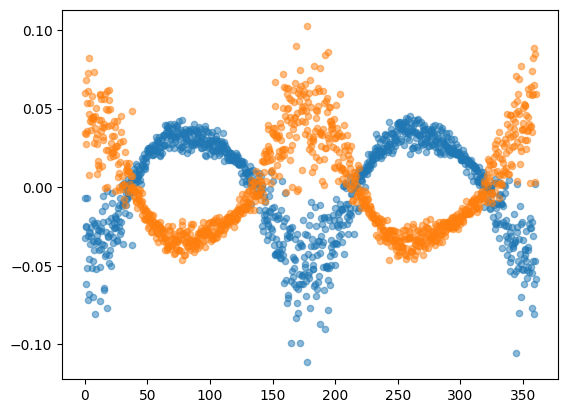

In [949]:
plt.scatter(np.linspace(0, 360, evecs1.shape[0]), evecs1[:, 0], s=20, alpha=0.5)
plt.scatter(np.linspace(0, 360, evecs2.shape[0]), evecs2[:, 0], s=20, alpha=0.5)
plt.show()

In [1024]:
response_z[:, :, 0]

array([[-0.4940521 , -0.4940521 , -0.26566015, ..., -0.4940521 ,
        -0.4940521 , -0.4940521 ],
       [-0.51964592, -0.51964592, -0.51964592, ..., -0.51964592,
        -0.51964592, -0.51964592],
       [-0.33150027, -0.35068478, -0.35068478, ..., -0.35068478,
        -0.35068478, -0.23170183],
       ...,
       [-0.55701358, -0.65700645,  0.18147473, ..., -0.67770385,
        -0.67770385, -0.60703638],
       [ 0.90068885,  0.50959546,  2.31262161, ...,  0.59906574,
        -0.76784834,  2.75746364],
       [-0.59986504, -0.59986504, -0.25152824, ..., -0.30238798,
        -0.59986504,  2.10579255]], shape=(1092, 1024))

In [1294]:
response_z = np.ascontiguousarray(response_z, dtype=np.float64)

In [1299]:
def cross_cov(Fa, Fb):
    return (Fa.T @ Fb + Fb.T @ Fa) / (2 * Fa.shape[0])

def cvpca(F1, F2, F3, nmax=None):
    """Compute cross-validated eigenvalue spectrum."""
    M12 = cross_cov(F1, F2)
    _, V = np.linalg.eigh(M12)
    V = V[:, ::-1]     # eigenvectors descending
    if nmax is not None:
        V = V[:, :nmax]
    M23 = F2.T @ F3 / F3.shape[0]
    M13 = F1.T @ F3 / F3.shape[0]
    lam1 = np.array([V[:, i].T @ M23 @ V[:, i] for i in range(V.shape[1])])
    lam2 = np.array([V[:, i].T @ M13 @ V[:, i] for i in range(V.shape[1])])
    lam = (lam1 + lam2) / 2
    return lam

def sym_cvpca(F1, F2, F3, nmax=None):
    """Compute symmetric cross-validated PCA."""
    lam1 = cvpca(F1, F2, F3, nmax=nmax)
    lam2 = cvpca(F2, F3, F1, nmax=nmax)
    lam3 = cvpca(F3, F1, F2, nmax=nmax)
    return (lam1 + lam2 + lam3) / 3


In [1297]:
R1 = np.ascontiguousarray(response_z[:, :, 0], dtype=np.float64)
R2 = np.ascontiguousarray(response_z[:, :, 1], dtype=np.float64)
R3 = np.ascontiguousarray(response_z[:, :, 2], dtype=np.float64)

In [1311]:
# we have 1094 cells but seems like we can get at most a few hundred good dimensions from the data.
# I think a good approach is to choose a subset of cells, and compute the spectrum many times
# to get a better estimate of the variability.

n_bootstraps = 128
n_cells_sub = 512
evals = np.zeros((n_bootstraps, n_cells_sub))

for i in range(n_bootstraps):
    # Randomly select a subset of cells
    cell_indices = np.random.choice(response_z.shape[0], n_cells_sub, replace=False)
    F1 = R1[cell_indices, :]
    F2 = R2[cell_indices, :]
    F3 = R3[cell_indices, :]
    evals[i] = sym_cvpca(F1, F2, F3, nmax=n_cells_sub)
    if i%10 == 0:
        print(f"Bootstrap iteration {i}")


Bootstrap iteration 0
Bootstrap iteration 10
Bootstrap iteration 20
Bootstrap iteration 30
Bootstrap iteration 40
Bootstrap iteration 50
Bootstrap iteration 60
Bootstrap iteration 70
Bootstrap iteration 80
Bootstrap iteration 90
Bootstrap iteration 100
Bootstrap iteration 110
Bootstrap iteration 120


/tmp/ipykernel_1417653/1913247794.py:5: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, n_cells_sub + 1)), np.log(eval_median), s=10, alpha=0.5, label='median')


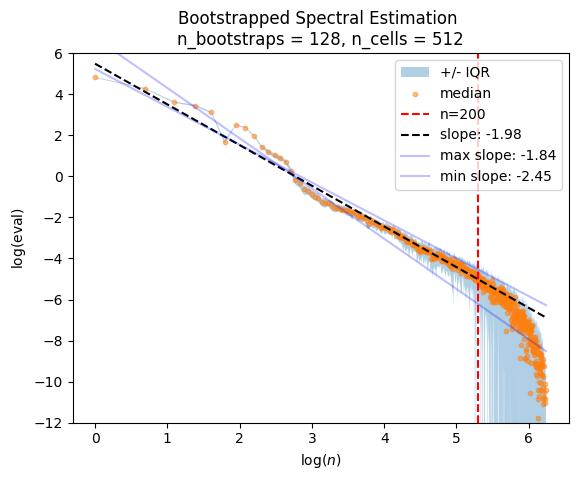

In [1343]:
eval_median = np.median(evals, axis=0)
lower = np.percentile(evals, 30, axis=0).clip(min=1e-15)
upper = np.percentile(evals, 70, axis=0)
plt.fill_between(np.log(np.arange(1, n_cells_sub + 1)), np.log(lower), np.log(upper), alpha=0.35, label='+/- IQR')
plt.scatter(np.log(np.arange(1, n_cells_sub + 1)), np.log(eval_median), s=10, alpha=0.5, label='median')
# plt.plot(np.log(np.arange(1, n_cells_sub + 1)), np.log(lower.clip(min=1e-15)), alpha=0.2)
plt.ylim(-12, 6)
plt.vlines(np.log(200), -12, 6, colors='r', linestyles='dashed', label='n=200')
# fit line to all points below 200
coeffs = np.polyfit(np.log(np.arange(1, 201)), np.log(eval_median[:200]), 1)
plt.plot(np.log(np.arange(1, n_cells_sub + 1)), coeffs[1] + coeffs[0] * np.log(np.arange(1, n_cells_sub + 1)), 'k--', label=f'slope: {coeffs[0]:.2f}')
# fit lower and upper bound line
coeffs_lower = np.polyfit(np.log(np.arange(1, 201)), np.log(lower[:200]), 1)
coeffs_upper = np.polyfit(np.log(np.arange(1, 201)), np.log(upper[:200]), 1)
plt.plot(np.log(np.arange(1, n_cells_sub + 1)), coeffs_upper[1] + coeffs_upper[0] * np.log(np.arange(1, n_cells_sub + 1)), 'b', 
         label=f'max slope: {coeffs_upper[0]:.2f}', alpha=0.25)
plt.plot(np.log(np.arange(1, n_cells_sub + 1)), coeffs_lower[1] + coeffs_lower[0] * np.log(np.arange(1, n_cells_sub + 1)), 'b', 
         label=f'min slope: {coeffs_lower[0]:.2f}', alpha=0.25)
plt.legend()
plt.xlabel(r'$\log(n)$')
plt.ylabel(r'$\log(\text{eval})$')
plt.title(f'Bootstrapped Spectral Estimation \nn_bootstraps = {n_bootstraps}, n_cells = {n_cells_sub}')
plt.show()

In [1344]:
evals_main = sym_cvpca(R1, R2, R3, nmax=n_cells)

/tmp/ipykernel_1417653/452290404.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, n_trials + 1)), np.log(evals_main), s=10, alpha=0.5)


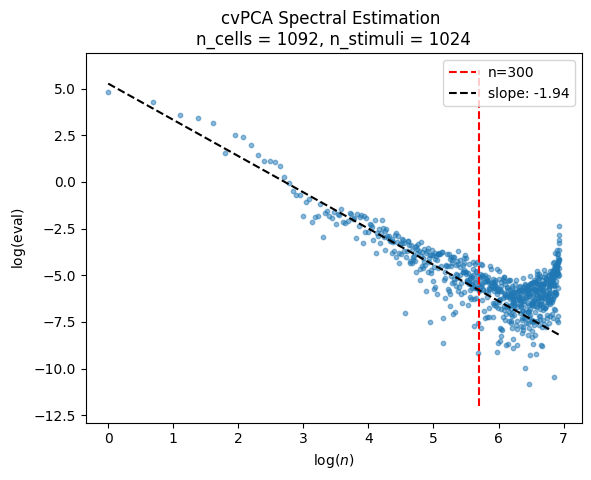

In [1366]:
plt.scatter(np.log(np.arange(1, n_trials + 1)), np.log(evals_main), s=10, alpha=0.5)
cutoff = 300
plt.vlines(np.log(cutoff), -12, 6, colors='r', linestyles='dashed', label=f'n={cutoff}')
# fit line to all points below cutoff
x = np.arange(1, cutoff + 1)
y = evals_main[:cutoff]
x = x[y > 1e-12]
y = y[y > 1e-12]
coeffs = np.polyfit(np.log(x), np.log(y), 1)
plt.plot(np.log(np.arange(1, n_trials + 1)), coeffs[1] + coeffs[0] * np.log(np.arange(1, n_trials + 1)), 'k--', label=f'slope: {coeffs[0]:.2f}')
plt.xlabel(r'$\log(n)$')
plt.ylabel(r'$\log(\text{eval})$')
plt.title(f'cvPCA Spectral Estimation \nn_cells = {n_cells}, n_stimuli = {n_trials}')
plt.legend()
plt.show()

In [1119]:
evals = np.zeros((6, 1024))
evals[0] = cv_spectrum(response_z[:, :, 0], response_z[:, :, 1], response_z[:, :, 2])
evals[1] = cv_spectrum(response_z[:, :, 1], response_z[:, :, 2], response_z[:, :, 0])
evals[2] = cv_spectrum(response_z[:, :, 2], response_z[:, :, 0], response_z[:, :, 1])
evals[3] = cv_spectrum(response_z[:, :, 1], response_z[:, :, 0], response_z[:, :, 2])
evals[4] = cv_spectrum(response_z[:, :, 2], response_z[:, :, 1], response_z[:, :, 0])
evals[5] = cv_spectrum(response_z[:, :, 0], response_z[:, :, 2], response_z[:, :, 1])

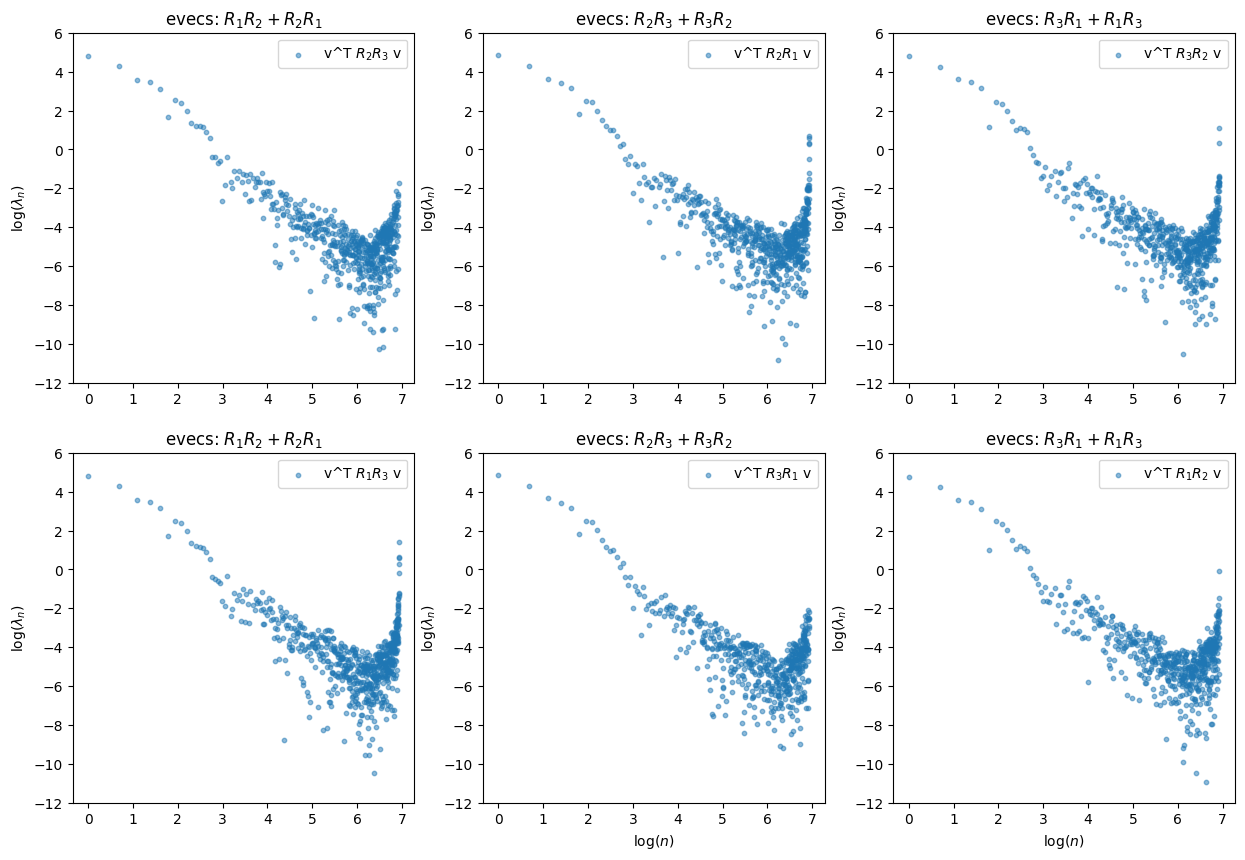

In [1131]:
x = np.log(np.arange(1, 1025))
y = np.log(evals.clip(1e-18, None))
plt.figure(figsize=(15, 10))
labels = [r'$R_1 R_2 + R_2 R_1$',
          r'$R_2 R_3 + R_3 R_2$',
          r'$R_3 R_1 + R_1 R_3$',
          r'$R_1 R_2 + R_2 R_1$',
          r'$R_2 R_3 + R_3 R_2$',
          r'$R_3 R_1 + R_1 R_3$']
proj_mat = [r'$R_2 R_3$', 
            r'$R_2 R_1$', 
            r'$R_3 R_2$', 
            r'$R_1 R_3$', 
            r'$R_3 R_1$',
            r'$R_1 R_2$']
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.scatter(x, y[i], alpha=0.5, s=10, label=rf'v^T {proj_mat[i]} v')
    if i > 3:
        plt.xlabel(r'$\log(n)$')
    plt.ylabel(r'$\log(\lambda_n)$')
    plt.title(f'evecs: {labels[i]}')
    plt.ylim(-12, 6)
    plt.legend()

plt.show()

/tmp/ipykernel_1417653/3091227811.py:3: RuntimeWarning: invalid value encountered in log
  evals_std = np.log(evals).std(axis=0)


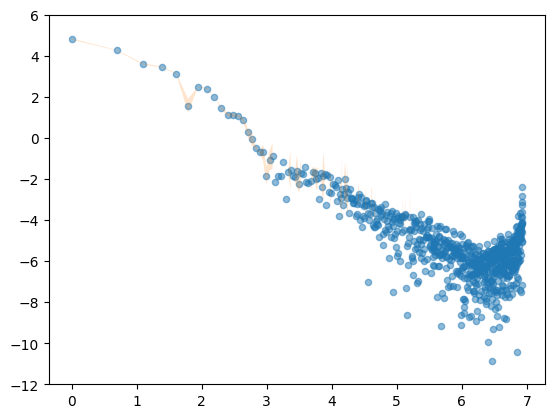

In [1141]:
x = np.log(np.arange(1, 1025))
evals_mean = evals.mean(axis=0)
evals_std = np.log(evals).std(axis=0)
evals_mean = np.log(evals_mean.clip(1e-18, None))
plt.scatter(x, evals_mean, s=20, alpha=0.5)
plt.fill_between(x, evals_mean - evals_std, evals_mean + evals_std, alpha=0.2)
plt.ylim(-12, 6)
plt.show()

In [1175]:
C_train = cross_cov(response_z[:, :, 0], response_z[:, :, 1])
C_test = cross_cov(response_z[:, :, 1], response_z[:, :, 2])
# generate a different shuffle for each cell
r_p = response_z.copy()
for c in range(r_p.shape[0]):
    r_p[c, :, 1] = r_p[c, np.random.permutation(r_p.shape[1]), 1]
    r_p[c, :, 2] = r_p[c, np.random.permutation(r_p.shape[1]), 2]
C_p = cross_cov(r_p[:, :, 1], r_p[:, :, 2])
evecs = np.linalg.eigh(C_train)[1][:, ::-1]
evals_test = np.array([evecs[:, i].T @ C_test @ evecs[:, i] for i in range(evecs.shape[1])])
evals_p = np.array([evecs[:, i].T @ C_p @ evecs[:, i] for i in range(evecs.shape[1])])


In [1203]:
v = evecs[:, 0]
# get loadings of v onto R2 and R3
a = v @ response_z[:, :, 1].T
b = v @ response_z[:, :, 2].T

# do this for all modes
loadings_2 = response_z[:, :, 1] @ evecs
loadings_3 = response_z[:, :, 2] @ evecs

In [1205]:
loadings_2

array([[ 14.29251593,  15.11956967,  10.48700987, ...,  -5.58987526,
         -4.01055367,   3.15757305],
       [ 12.14928655, -12.51424038, -19.77900886, ...,   1.72122493,
         -3.65392278,   2.92592422],
       [  5.75544495,  -4.77951622, -15.824887  , ...,   3.35064389,
         -7.84812161,   4.05388312],
       ...,
       [ 14.6324919 ,   9.21939418,  -1.34790628, ...,  -2.96574772,
         -4.92697259,   4.52245043],
       [-20.05290643,   3.19141517,   0.49399513, ...,   0.1426053 ,
         -1.38965342,   1.8782303 ],
       [ -6.69487865,   9.78857998,  -0.83162173, ...,  -2.05490108,
         -2.09611243,   3.42561318]], shape=(1092, 1024))

In [1222]:
correlation = np.zeros(1024)
C22 = response_z[:, :, 1].T @ response_z[:, :, 1] / response_z.shape[0]
C33 = response_z[:, :, 2].T @ response_z[:, :, 2] / response_z.shape[0]
C23 = response_z[:, :, 1].T @ response_z[:, :, 2] / response_z.shape[0]
C22 = np.ascontiguousarray(C22)
C33 = np.ascontiguousarray(C33)
C23 = np.ascontiguousarray(C23)
evecs = np.ascontiguousarray(evecs)
for i in range(1024):
    correlation[i] = evecs[:, i].T @ C23 @ evecs[:, i]
    correlation[i] /= np.sqrt(evecs[:, i].T @ C22 @ evecs[:, i]) * np.sqrt(evecs[:, i].T @ C33 @ evecs[:, i])

/tmp/ipykernel_1417653/2289780277.py:10: RuntimeWarning: invalid value encountered in sqrt
  correlation[i] /= np.sqrt(evecs[:, i].T @ C22 @ evecs[:, i]) * np.sqrt(evecs[:, i].T @ C33 @ evecs[:, i])


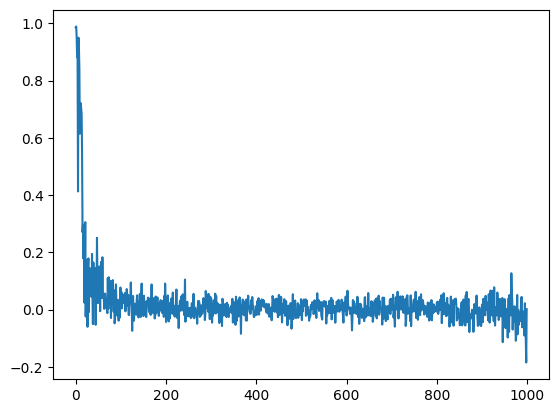

In [1226]:
plt.plot(correlation[:1000])

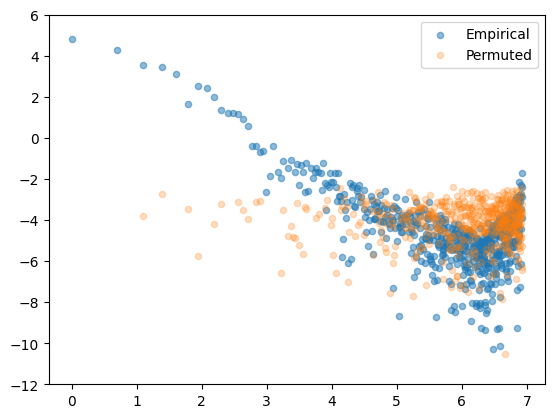

In [1176]:
x = np.log(np.arange(1, 1025))
y1 = np.log(evals_test.clip(1e-18, None))
y2 = np.log(evals_p.clip(1e-18, None))
plt.scatter(x, y1, s=20, alpha=0.5, label='Empirical')
plt.scatter(x, y2, s=20, alpha=0.25, label='Permuted')
plt.ylim(-12, 6)
plt.legend()
plt.show()

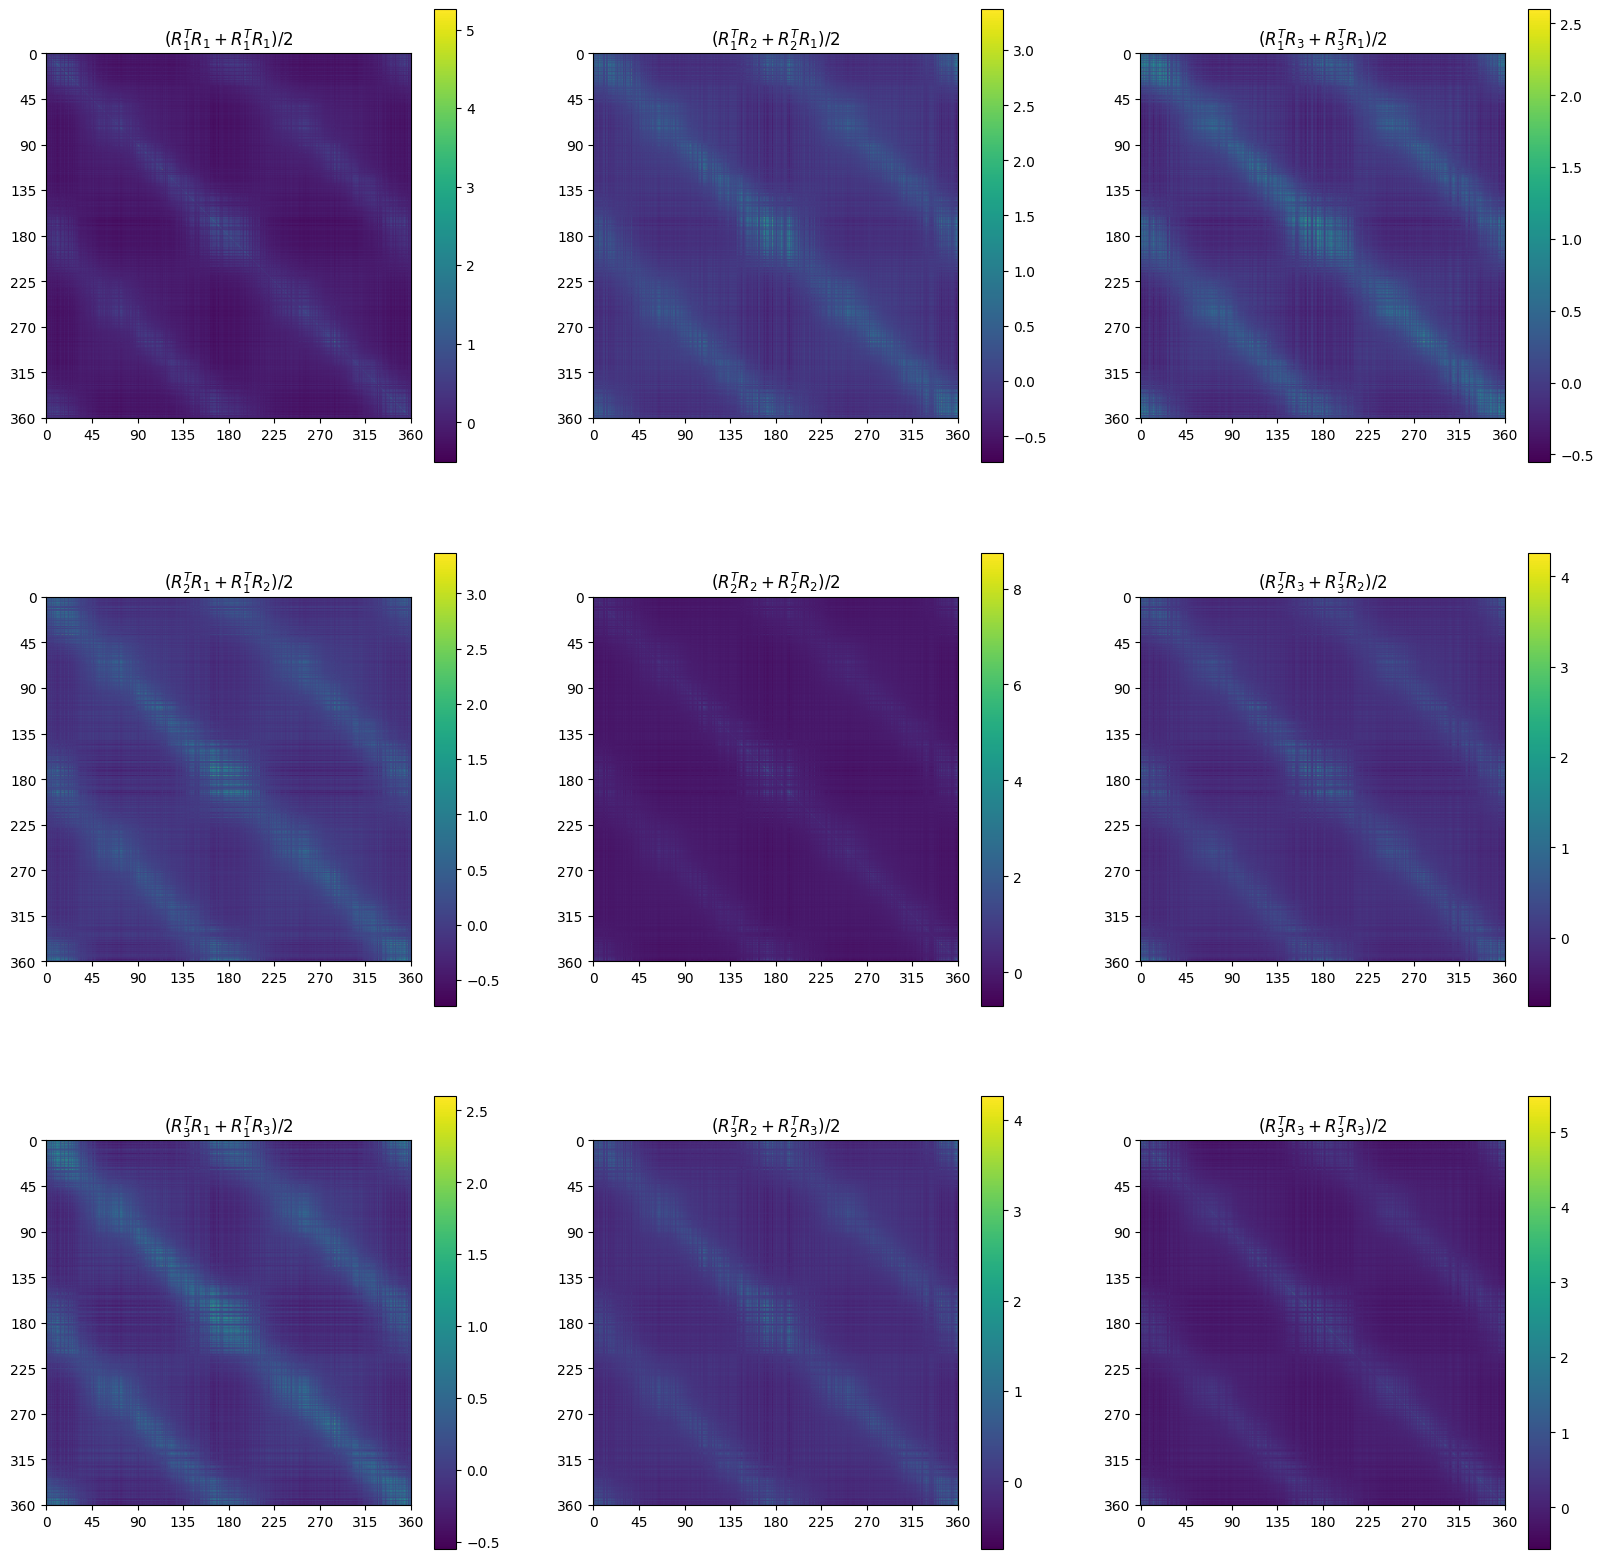

In [1158]:
fig, ax = plt.subplots(figsize=(20, 20), nrows=3, ncols=3)
for i, j in np.ndindex(3, 3):
    ax[i, j].imshow(C[:, :, i, j])
    ax[i, j].set_title(rf'$(R_{i+1}^T R_{j+1} + R_{j+1}^T R_{i+1})/2$')
    plt.colorbar(ax[i, j].imshow(C[:, :, i, j]), ax=ax[i, j])
    # change ticks from 0-1024 to 0-360
    ax[i, j].set_xticks(np.linspace(0, 1024, 9))
    ax[i, j].set_xticklabels(np.round(np.linspace(0, 360, 9)).astype(int))
    ax[i, j].set_yticks(np.linspace(0, 1024, 9))
    ax[i, j].set_yticklabels(np.round(np.linspace(0, 360, 9)).astype(int))
plt.show()

/tmp/ipykernel_1417653/948705442.py:4: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(evals.shape[1]) + 1), np.log(eval_mean), color='k', linestyle='-', label='Mean', s=20, alpha=0.5)


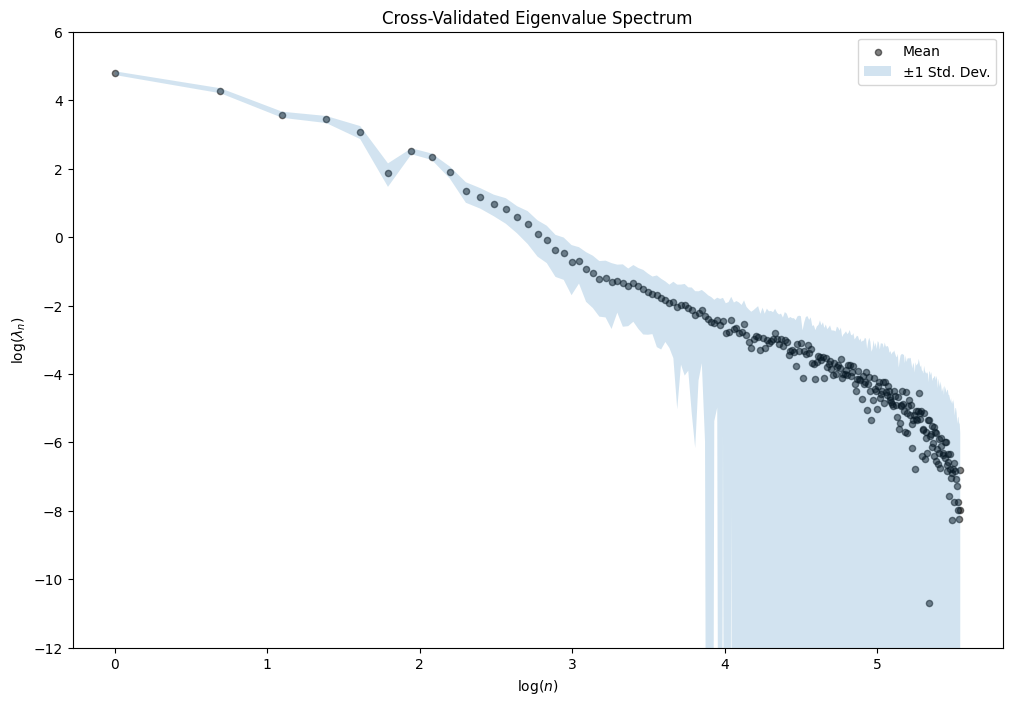

In [ ]:
# eval_mean = np.mean(evals, axis=0)
# eval_std = np.std(evals, axis=0)
# plt.figure(figsize=(12, 8))
# plt.scatter(np.log(np.arange(evals.shape[1]) + 1), np.log(eval_mean), color='k', linestyle='-', label='Mean', s=20, alpha=0.5)
# plt.fill_between(np.log(np.arange(evals.shape[1]) + 1), np.log(np.clip(eval_mean - eval_std, 1e-18, None)),
#                   np.log(eval_mean + eval_std), alpha=0.2, label='±1 Std. Dev.')
# # plt.vlines(np.log(60), ymin=-12, ymax=6, colors='r', linestyles='dashed', label='n=60')
# # fit a line to the data before n = 60
# # before_60 = np.log(np.arange(60) + 1)
# # after_60 = np.log(np.arange(60, evals.shape[1]) + 1)
# # coeffs = np.polyfit(before_60, np.log(eval_mean[:60]), 1)
# # coeffs_upper = np.polyfit(before_60, np.log(eval_mean[:60] + eval_std[:60]), 1)
# # coeffs_lower = np.polyfit(before_60, np.log(np.clip(eval_mean[:60] - eval_std[:60], 1e-18, None)), 1)
# # plt.plot(before_60, np.polyval(coeffs, before_60), color='k', linestyle='dashed', label=f'slope = {coeffs[0]:.2f}')
# # plt.plot(before_60, np.polyval(coeffs_lower, before_60), color='blue', linestyle=':', label=f'min_slope = {coeffs_lower[0]:.2f}', alpha=0.5)
# # plt.plot(before_60, np.polyval(coeffs_upper, before_60), color='blue', linestyle=':', label=f'max_slope = {coeffs_upper[0]:.2f}', alpha=0.5)
# plt.ylim(-12, 6)
# plt.xlabel(r'$\log(n)$')
# plt.ylabel(r'$\log(\lambda_n)$')
# plt.title('Cross-Validated Eigenvalue Spectrum')
# plt.legend()
# plt.show()

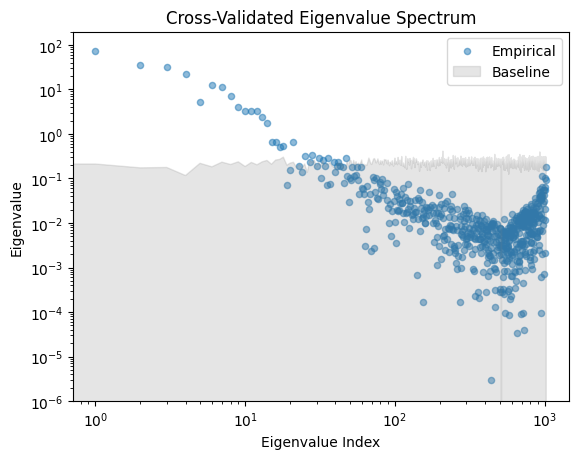

In [1042]:
plt.scatter(np.arange(len(evals)), evals, label='Empirical', s=20, alpha=0.5)
plt.fill_between(np.arange(len(evals)), lo, hi, color='gray', alpha=0.2, label='Baseline')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Cross-Validated Eigenvalue Spectrum')
plt.ylim(1e-6, 2 * 1e2)
plt.legend()
plt.show()

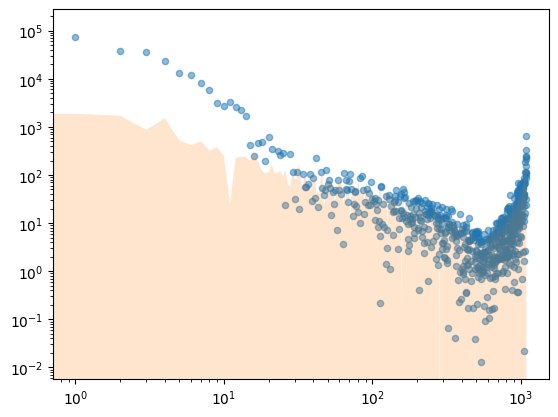

In [1016]:
plt.scatter(np.arange(len(evals)), evals, s=20, alpha=0.5)
plt.fill_between(np.arange(len(mean)), low, high, alpha=0.2)
plt.yscale('log')
plt.xscale('log')
plt.show()

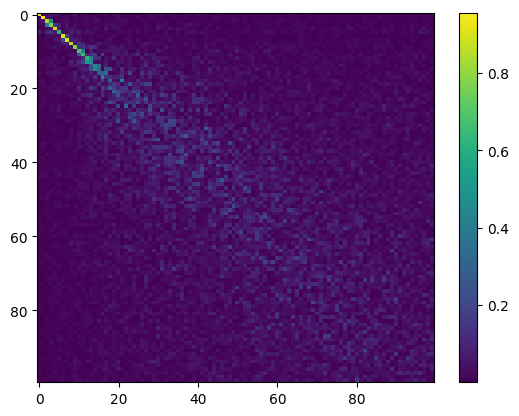

In [953]:
plt.imshow(corr[:100, :100], aspect='auto')
plt.colorbar()
plt.show()

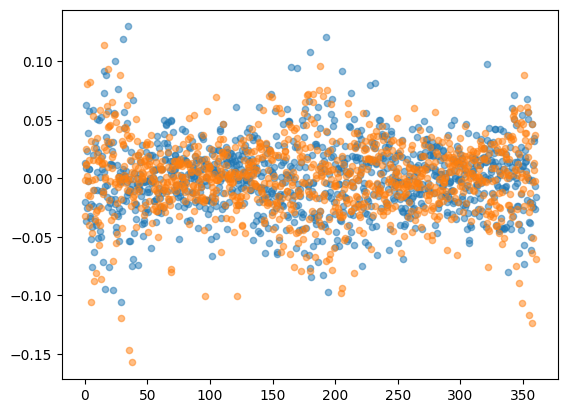

In [1004]:
rank = rank+1
factor = np.sign(evecs2[:, rank].T @ evecs1[:, rank])
plt.scatter(np.linspace(0, 360, evecs1.shape[0]), evecs1[:, rank], s=20, alpha=0.5)
plt.scatter(np.linspace(0, 360, evecs2.shape[0]), factor * evecs2[:, rank], s=20, alpha=0.5)
plt.show()

/tmp/ipykernel_1417653/3659996261.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(np.arange(len(evals))), np.log(evals))
/tmp/ipykernel_1417653/3659996261.py:1: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(np.arange(len(evals))), np.log(evals))


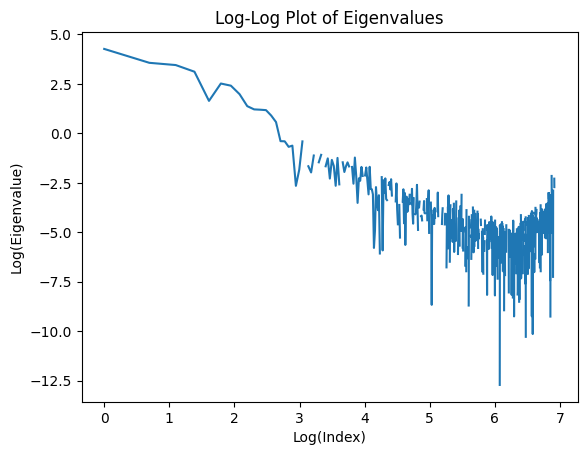

In [928]:
plt.plot(np.log(np.arange(len(evals))), np.log(evals))
plt.xlabel('Log(Index)')
plt.ylabel('Log(Eigenvalue)')
plt.title('Log-Log Plot of Eigenvalues')
plt.show()

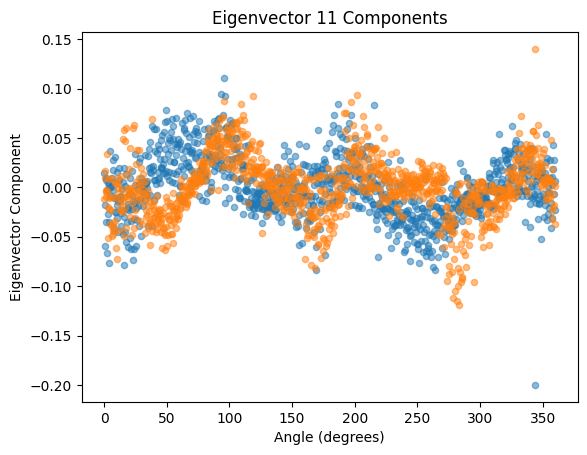

In [937]:
for i in range(10, 12):
    plt.scatter(np.linspace(0, 360, evecs.shape[0]), evecs[:, i], s=20, alpha=0.5)
plt.xlabel('Angle (degrees)')
plt.ylabel('Eigenvector Component')
plt.title(f'Eigenvector {i} Components')
plt.show()

In [ ]:
evecs = np.linalg.eigh(C[:, :, 0, 1] + C[:, :, 1, 0])[1][:, ::-1]
evals = np.array([evecs[:, i].T @ C[:, :, 1, 2] @ evecs[:, i] for i in range(evecs.shape[1])])

/tmp/ipykernel_1417653/3757142093.py:3: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals[0])+1)), np.log(evals[i]), s=20, alpha=0.1, c='orange')
/tmp/ipykernel_1417653/3757142093.py:4: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals[0])+1)), np.log(evals[0]), s=20, alpha=0.5, label=r'$v^T C_{23} v$')
/tmp/ipykernel_1417653/3757142093.py:13: RuntimeWarning: invalid value encountered in log
  y = np.log(evals[0][mask])


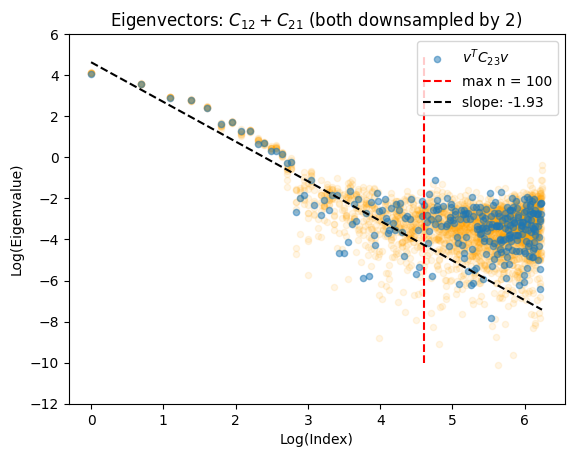

In [922]:
# for each scatter point, we have n bootstraps. Plot these as error bars
for i in range(1, n_bootstraps + 1):
    plt.scatter(np.log(np.arange(1, len(evals[0])+1)), np.log(evals[i]), s=20, alpha=0.1, c='orange')
plt.scatter(np.log(np.arange(1, len(evals[0])+1)), np.log(evals[0]), s=20, alpha=0.5, label=r'$v^T C_{23} v$')
# plot a line to the data
start, end = 0, 100
mask = (np.arange(1, len(evals[0])+1) < end) & (np.arange(1, len(evals[0])+1) > start)
is_finite = np.isfinite(evals[0])
mask = mask * is_finite
# Add vlines for mask
plt.vlines(np.log(end), -10, 5, colors='r', linestyles='dashed', label=f'max n = {end}')
x = np.log(np.arange(1, len(evals[0])+1)[mask])
y = np.log(evals[0][mask])

# Filter out invalid values
valid_mask = np.isfinite(x) & np.isfinite(y)
x = x[valid_mask]
y = y[valid_mask]

# Get slope and intercept
p = np.polyfit(x, y, 1)
x = np.log(np.arange(1, len(evals[0])+1))
plt.plot(x, np.polyval(p, x), 'k--', label=f'slope: {p[0]:.2f}')
plt.legend()
plt.ylabel('Log(Eigenvalue)')
plt.xlabel('Log(Index)')
plt.title(r'Eigenvectors: $C_{12} + C_{21}$ (both downsampled by 2)')
plt.ylim(-12,6)
plt.show()

/tmp/ipykernel_1417653/1849272260.py:1: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(evals)[:, :100], aspect='auto', origin='lower')


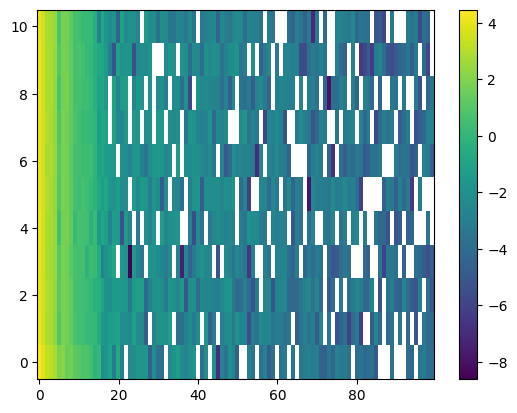

In [919]:
plt.imshow(np.log(evals)[:, :100], aspect='auto', origin='lower')
plt.colorbar()
plt.show()

/tmp/ipykernel_1417653/3413930653.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals)+1)), np.log(evals), s=20, alpha=0.5, label=r'$v^T C_{23} v$')
/tmp/ipykernel_1417653/3413930653.py:8: RuntimeWarning: divide by zero encountered in log
  plt.vlines([np.log(start), np.log(end)], -10, 5, colors='r', linestyles='dashed', label=f'max n = {end}')
/tmp/ipykernel_1417653/3413930653.py:10: RuntimeWarning: invalid value encountered in log
  y = np.log(evals[mask])


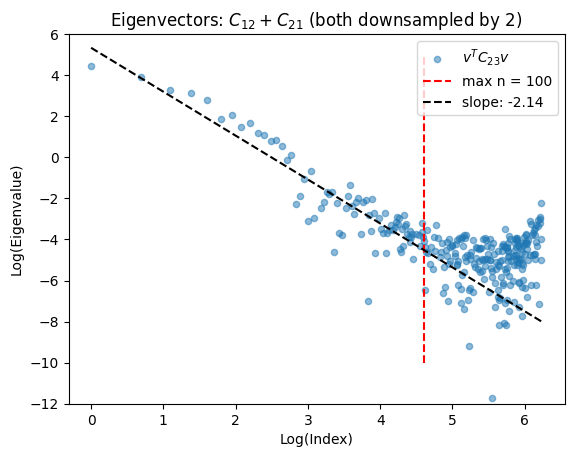

In [895]:
plt.scatter(np.log(np.arange(1, len(evals)+1)), np.log(evals), s=20, alpha=0.5, label=r'$v^T C_{23} v$')
# plot a line to the data
start, end = 0, 100
mask = (np.arange(1, len(evals)+1) < end) & (np.arange(1, len(evals)+1) > start)
is_finite = np.isfinite(evals)
mask = mask * is_finite
# Add vlines for mask
plt.vlines([np.log(start), np.log(end)], -10, 5, colors='r', linestyles='dashed', label=f'max n = {end}')
x = np.log(np.arange(1, len(evals)+1)[mask])
y = np.log(evals[mask])

# Filter out invalid values
valid_mask = np.isfinite(x) & np.isfinite(y)
x = x[valid_mask]
y = y[valid_mask]

# Get slope and intercept
p = np.polyfit(x, y, 1)
x = np.log(np.arange(1, len(evals)+1))
plt.plot(x, np.polyval(p, x), 'k--', label=f'slope: {p[0]:.2f}')
plt.legend()
plt.ylabel('Log(Eigenvalue)')
plt.xlabel('Log(Index)')
plt.title(r'Eigenvectors: $C_{12} + C_{21}$ (both downsampled by 2)')
plt.ylim(-12,6)
plt.show()

/tmp/ipykernel_1417653/3982601412.py:2: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals_sub)+1)), np.log(evals_sub), s=20, alpha=0.5)


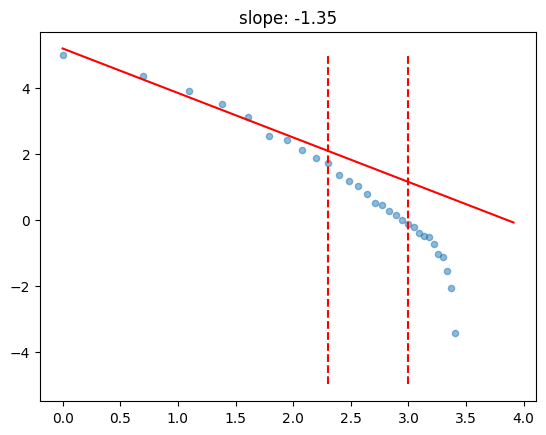

In [728]:
evals_sub = np.linalg.eigvalsh(C_subset)[::-1]
plt.scatter(np.log(np.arange(1, len(evals_sub)+1)), np.log(evals_sub), s=20, alpha=0.5)
# plot a line to the data
mask = (np.arange(1, len(evals_sub)+1) < 20) & (evals_sub > 10)
# add vlines for mask
plt.vlines([np.log(10), np.log(20)], -5, 5, colors='r', linestyles='dashed')
x = np.log(np.arange(1, len(evals_sub)+1)[mask])
y = np.log(evals_sub[mask])
fit = np.polyfit(x, y, 1)
x = np.log(np.arange(1, len(evals_sub)+1))
plt.plot(x, fit[0] * x + fit[1], color='red')
plt.title(f'slope: {fit[0]:.2f}')
plt.show()

In [625]:
evals2 = np.linalg.eigvalsh(G)[::-1]
evals3 = np.linalg.eigvalsh(C)[::-1]

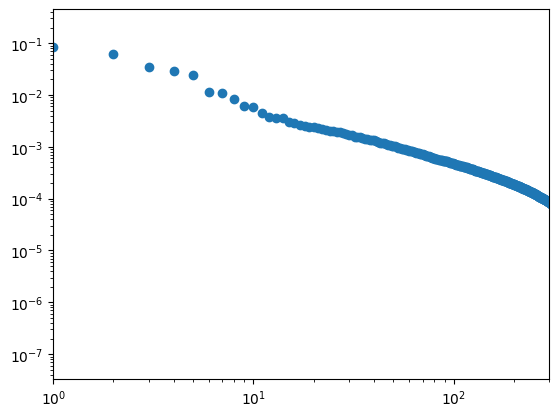

In [622]:
plt.scatter(np.arange(len(evals2)), evals2)
# plt.vlines(250, 0, 0.1, colors='r', linestyles='dashed')
# plot on log-log
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, 300)
# plt.ylim(1e-2, 1e1)
plt.show()

/tmp/ipykernel_1417653/791911589.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals2)+1)), np.log(evals2), s=20, alpha=0.5)
/tmp/ipykernel_1417653/791911589.py:2: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(np.arange(1, len(evals3)+1)), np.log(evals3), s=20, alpha=0.5)


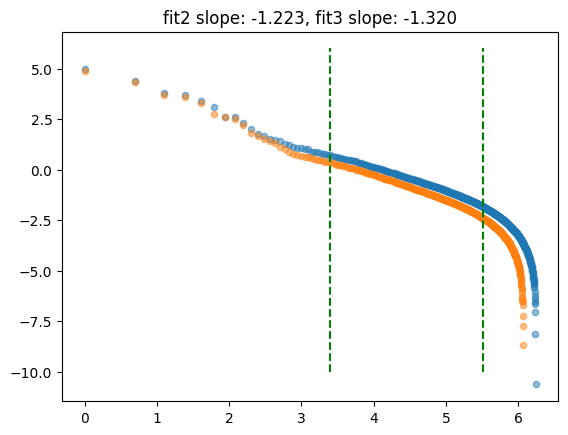

In [631]:
plt.scatter(np.log(np.arange(1, len(evals2)+1)), np.log(evals2), s=20, alpha=0.5)
plt.scatter(np.log(np.arange(1, len(evals3)+1)), np.log(evals3), s=20, alpha=0.5)
# fit lines to values between n=30 and n=250
mask = (np.arange(1, len(evals2)+1) >= 30) & (np.arange(1, len(evals2)+1) <= 250)
fit2 = np.polyfit(np.log(np.arange(1, len(evals2)+1)[mask]), np.log(evals2[mask]), 1)
fit3 = np.polyfit(np.log(np.arange(1, len(evals3)+1)[mask]), np.log(evals3[mask]), 1)
# plot vertical lines at n=30 and n=250
plt.vlines([np.log(30), np.log(250)], -10, 6, colors='g', linestyles='dashed')
# plot fit line
# x = np.log(np.arange(1, len(evals2)+1))
# plt.plot(x, fit2[0] * x + fit2[1], 'r--')
# plt.plot(x, fit3[0] * x + fit3[1], 'b--')
plt.title(f'fit2 slope: {fit2[0]:.3f}, fit3 slope: {fit3[0]:.3f}')
# plt.ylim(-3,1)
# plt.xlim(3,6)
plt.show()


In [75]:
matlab_file_dir = '/home/reilly/Desktop/jacob data/meta2.mat'
mat_data = sc.io.loadmat(matlab_file_dir, simplify_cells=True)

In [76]:
# Extract grating orientations
grating_orients = np.array([entry['gratingOrient'] for entry in mat_data['block']['paramsValues']])

In [78]:
# get unique orientations and their counts
unique_orients, counts = np.unique(grating_orients, return_counts=True)
counts

array([1, 1, 1, ..., 1, 1, 1], shape=(1025,))

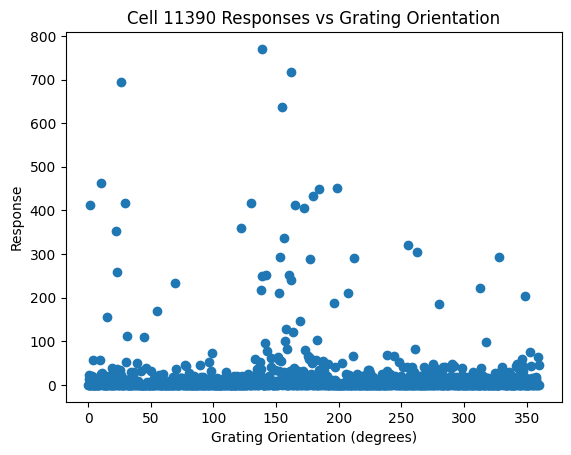

In [136]:
cell_index = np.random.randint(data.shape[1])
plt.scatter(grating_orients, data[:, cell_index])
plt.xlabel('Grating Orientation (degrees)')
plt.ylabel('Response')
plt.title(f'Cell {cell_index} Responses vs Grating Orientation')
plt.show()

In [63]:
# for each unique orientation, count the number of occurrences
unique_orients, counts = np.unique(grating_orients, return_counts=True)


(array([ 44., 264., 716.]),
 array([2., 3., 4., 5.]),
 <BarContainer object of 3 artists>)

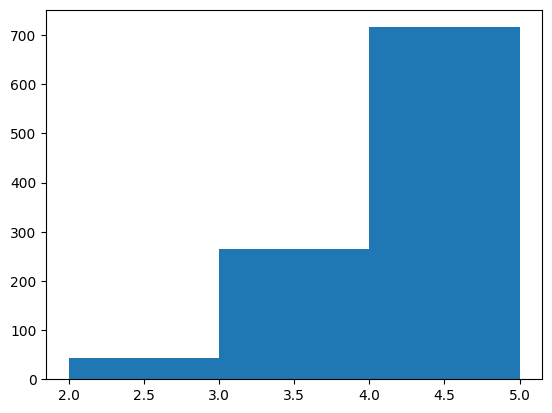

In [68]:
plt.hist(counts, bins=[2,3,4,5])

In [9]:
census = np.load('program_databases/07-23/00-21-26 (image)/combined/census.npy', allow_pickle=True)
y_eval = census[:, -1]
n_programs = census.shape[0]

In [16]:
y_eval[0].shape

(1055, 100)

Evaluating outputs for cell index: 1


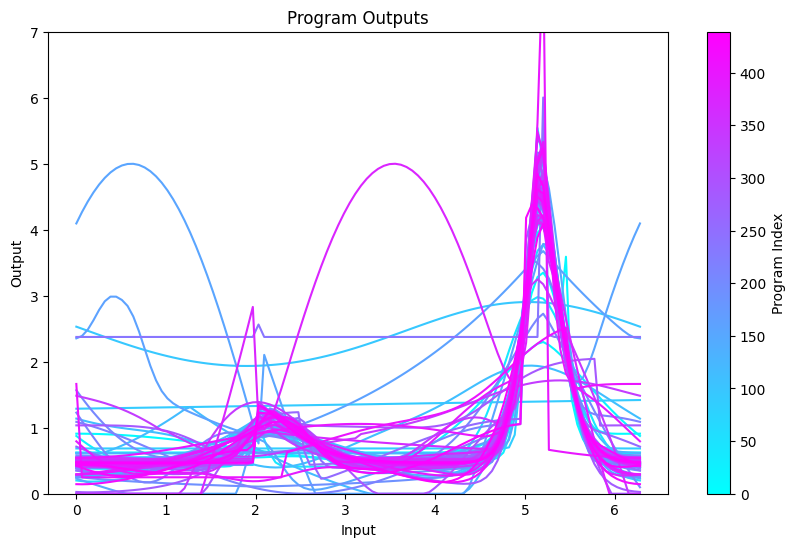

In [92]:
cell_index = 1
print(f"Evaluating outputs for cell index: {cell_index}")
x = np.linspace(0, 2*np.pi, 100)
# add a colormap that we will use to indicate different programs
cmap = plt.get_cmap('cool', n_programs)

plt.figure(figsize=(10, 6))
for i in range(0, n_programs, 5):
    y = y_eval[i][cell_index, :]
    plt.plot(x, y, color=cmap(i))
plt.title('Program Outputs')
plt.xlabel('Input')
plt.ylabel('Output')
# Create a scatter plot to have a mappable for the colorbar
scatter = plt.scatter([], [], c=[], cmap='cool', vmin=0, vmax=n_programs-1)
plt.colorbar(scatter, label='Program Index')
plt.ylim(0, 7)
plt.show()


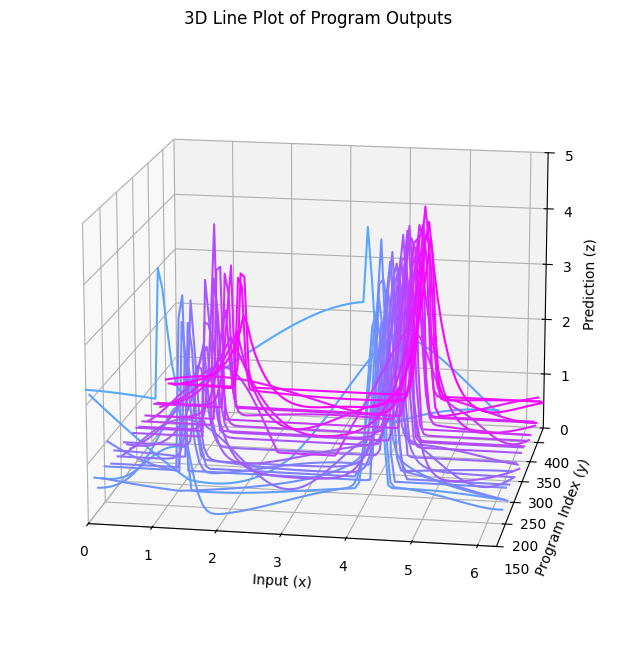

In [91]:
from mpl_toolkits.mplot3d import Axes3D

cell_index = 14
x = np.linspace(0, 2*np.pi, 100)
y = np.arange(n_programs - 150)
X, Y = np.meshgrid(x, y)
Z = np.array([y_eval[i][cell_index, :] for i in range(150, n_programs)])
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot a line for each program with depth shading
for i in range(0, Z.shape[0], 10):
    ax.plot(x, np.full_like(x, i + 150), Z[i], color=cmap(i + 150), label=f'Program {i + 150}')
ax.set_title('3D Line Plot of Program Outputs')
ax.set_xlabel('Input (x)')
ax.set_ylabel('Program Index (y)')
ax.set_zlabel('Prediction (z)')
ax.set_ylim3d(150, n_programs - 1)
ax.set_xlim3d(0, 2 * np.pi)
ax.set_zlim3d(0, 5)
# change view angle
ax.view_init(elev=15, azim=280)
plt.show()
